# Malaria cases in africa
 Data analysis investigation - Mark Andrews | partner: Tyler hann | 2DGT20

In [ ]:
import pandas as pd
import sys
import matplotlib.pyplot as plt
df = pd.read_excel('DatasetAfricaMalaria.xlsx')

# Introduction
## Dataset overview
#### This investigation looks into the correlation between reported cases of malaria across Africa and access to essential healthcare, specifically sanitation and drinking water services. It investigates whether improvements in access to clean drinking water and sanitation are associated with changes in the number of reported malaria cases over time. If a relationship can be identified, it may provide insight into the importance of these services in decreasing the impact of malaria in Africa. The dataset has records of reported malaria cases across multiple African countires over the span of 10 years (2007 - 2017). The dataset has 595 rows across 27 columns, with multiple records of data from each year for each country.
## Provenance
#### The dataset has been provided by a data scientist called Tassawar Abbas who has shared this dataset on a reliable data site known as kaggle where it has the highest usability rating. The dataset provides a multi-dimensional view of the malaria epidemic in Africa, tracking critical health, environmental, and demographic metrics over a decade (2007–2017). It is a vital resource for researchers, epidemiologists, and data scientists looking to analyze the correlations between public health interventions, basic infrastructure, and malaria prevalence. 

# Research question and Hypothesis
#### Research Question: Is there a relationship between malaria cases and access to essential health services across countries? Hypothesis: Years with a closer date should have increased malaria cases and increased essential health services, this is because the population should increase over time, and more people means more reported malaria cases and most likely more essential health services to accommodate the greater population. Ethical considerations: The investigation will use public available data, meaning no personal information or direct participation from individuals is involved. Sources will be referenced for honesty and reliability. Data will also be interpreted carefully so there is no misleading conclusions or assumptions about countries being studied.
## Initial inspection

## Cleaning decisions


count    5.500000e+02
mean     1.068330e+06
std      2.192802e+06
min      0.000000e+00
25%      2.211750e+03
50%      1.130260e+05
75%      1.154808e+06
max      1.682113e+07
Name: Malaria cases reported, dtype: float64


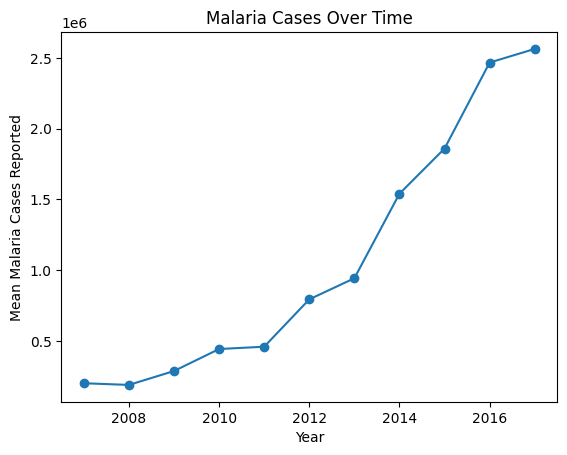

In [ ]:
import sys
import matplotlib.pyplot as plt

df = pd.read_excel('DatasetAfricaMalaria.xlsx')

# remove duplicates and null values
df = df.dropna(how='all')
df.isnull().sum()

# check for duplicates
df[df.duplicated(keep=False)]
df.duplicated().sum()

# check for outliers in the 'Malaria cases reported' column
print(df['Malaria cases reported'].describe())



# Exploratory Analysis
(talk about stuff here)
## Visualisation plan

## Partner contribution - Tyler Hann
#### Tyler found that the exploratory analysis identified several important patterns in the malaria dataset across African countries between 2007 and 2017. A strong positive relationship was observed between population at risk and reported malaria cases. Countries with larger populations at risk generally reported higher numbers of malaria cases, indicating that total case burden tends to increase as the number of people exposed to malaria increases. However, considerable variation was present at similar population levels, suggesting that population size alone does not determine malaria outcomes. When total population and total malaria cases were compared over time, both variables increased steadily throughout the study period. This trend suggests that overall population growth was accompanied by an increase in the total number of reported malaria cases. The data did not show evidence that larger populations experienced lower overall malaria burdens.

#### An average health access score was created using available water and sanitation indicators to investigate whether improved access to basic services was associated with lower malaria cases. Health access generally improved over the study period, indicating progress in access to water and sanitation infrastructure. However, malaria cases also increased during the same period. This suggests that improvements in general service access alone were not associated with reductions in total malaria case numbers within this dataset. The findings indicate that malaria transmission is influenced by multiple factors beyond population size and access to basic services. Variables such as climate conditions, mosquito habitats, disease prevention programs, healthcare quality, and socioeconomic conditions may also contribute significantly to malaria outcomes. Overall, the exploratory analysis found that higher populations tended to be associated with higher total malaria case counts, while improvements in health access did not correspond with a clear reduction in malaria cases. These results suggest that the original hypothesis was not strongly supported by the available data and that further investigation using additional variables would be required to better understand the factors affecting malaria prevalence.

#### Additionally, Tyler also created the health columns list used in multiple of our findings:
    health_cols = [
       'People using safely managed drinking water services (% of population)',
      'People using safely managed sanitation services (% of population)',
      'People using at least basic drinking water services (% of population)',
      'People using at least basic sanitation services (% of population)'
    ]

In [8]:



# all the health columns in the dataset
health_cols = [
    'People using safely managed drinking water services (% of population)',
    'People using safely managed sanitation services (% of population)',
    'People using at least basic drinking water services (% of population)',
    'People using at least basic sanitation services (% of population)'
]

#tyler code here



# Analysis and Visualisation
## Chart 1
#### The first graph shown shows the mean of the malaria reports for each country from each year (Note that its in decimals because its x10^6). The graph itself is an exponential trend instead of a linear one, which implies that the rate at which malaria cases were reported accelerated over time rather than increasing constantly.
## Chart 2
#### The second graph is a scatterplot graph that has a dot, each dot is a malaria cases from a country from a year (this includes the same country from multiple years and multiple countries from the same year). It shows that when there was a higher value for average essential health services, there were fewer malaria cases. 


# REMEMBER limitations: only covers 10 years

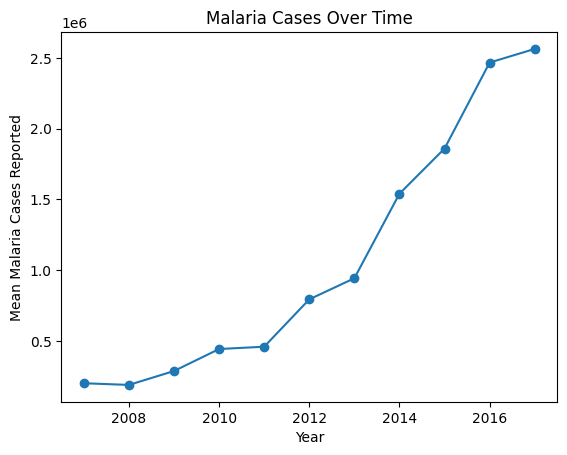

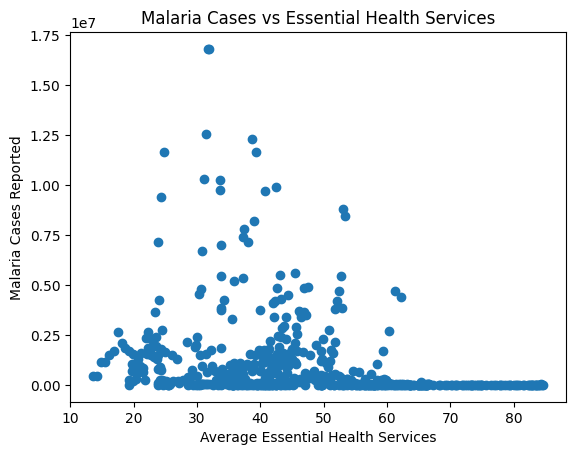

In [7]:
health_cols = [
    'People using safely managed drinking water services (% of population)',
    'People using safely managed sanitation services (% of population)',
    'People using at least basic drinking water services (% of population)',
    'People using at least basic sanitation services (% of population)'
]

malaria_by_year = df.groupby('Year')['Malaria cases reported'].mean()
plt.plot(malaria_by_year.index, malaria_by_year.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Mean Malaria Cases Reported')
plt.title('Malaria Cases Over Time')
plt.show()

health_average = df[health_cols].mean(axis=1)
plt.scatter(health_average,
df['Malaria cases reported'])
plt.xlabel('Average Essential Health Services')
plt.ylabel('Malaria Cases Reported')
plt.title('Malaria Cases vs Essential Health Services')
plt.show()